# Bottleneck & Latent Space Optimization Analysis

In this notebook, we'll focus specifically on the bottleneck architecture optimization:

```
latent-space → Reshape(Nlat-space, 1, 1, 1) → Upsampling3D(Nlat-space, Nx, Ny, Nz) 
→ Conv3D(Nlat-space, Nlat-space, (Nx, Ny, Nz), groups = Nlat-space) 
→ Conv3D(Nlat-space, Nchan, 1) → Activation
```

This approach associates each latent space variable with a "basis image" and combines them
by weighing them by the latent space intensity, significantly reducing parameter count.

## Setup & Imports

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm.auto import tqdm


# Runtime reload
import importlib
import models.autoencoder.selected_model
importlib.reload(models.autoencoder.selected_model)


from data.data_ingestion import collect_files, generate_dataframe
from data.dataloader import create_dataloaders
from models.autoencoder.selected_model import (
    BaseEncoder,
    BaseDecoder,
    BottleneckEncoder,
    BottleneckBasisDecoder,
    BottleneckHybridDecoder,
    BottleneckDeconvDecoder,
    BottleneckAE,
    SpatialAE,
    BottleneckBasisDecoderFixed,
    BottleneckDeconvDecoderFixed
)
from models.autoencoder.training import train_autoencoder
from models.autoencoder.config import TrainingConfig


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def save_model(m, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save(m.state_dict(), path)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Device: cuda


## Data setup

In [27]:
root_dir = Path(".")
images_dir = root_dir / "data" / "Images"
mask_path = root_dir / "data" / "masks" / "rmask_ICV.nii"

# Configuration
data_dir = "data/Images"
mask_path = "data/masks/rmask_ICV.nii"
batch_size = 4
output_dir = "output/Experiments/NotebookBottelneckUpdate"

# Create output directory
os.makedirs(output_dir, exist_ok=True)

In [16]:
# Prepare data
print("Collecting files...")
included_files, excluded_files = collect_files(data_dir)
print(f"Found {len(included_files)} valid files, excluded {len(excluded_files)} files")

# Generate dataframe
print("Generating dataframe...")
df = generate_dataframe(included_files)
display(df.head())

# Create dataloaders
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    df, batch_size=batch_size, train_split=0.8, 
    on_demand=True, mask_path=mask_path
)

print(f"Data preparation complete. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Found 2976 valid files, excluded 893 files
Generating dataframe...


,file_path,label
0,data/Images/PPMI_Images_Cont/100004/Reconstruc...,Control
1,data/Images/PPMI_Images_Cont/100890/Reconstruc...,Control
2,data/Images/PPMI_Images_Cont/100956/Reconstruc...,Control
3,data/Images/PPMI_Images_Cont/101039/Reconstruc...,Control
4,data/Images/PPMI_Images_Cont/101195/Reconstruc...,Control


Creating dataloaders...

Training set distribution:
label
PD         2035
Control     235
SWEDD       110
Name: count, dtype: int64

Validation set distribution:
label
PD         510
Control     59
SWEDD       27
Name: count, dtype: int64
Using on-demand data loading strategy (lighter on memory but slower)
✅ Brain mask loaded successfully
✅ All 2380 file paths are valid
✅ Brain mask loaded successfully
✅ All 596 file paths are valid
Data preparation complete. Train: 2380, Val: 596


## Model Setup

In [28]:
target_shape = (64, 128, 128)

def build_model(variant, latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="partial"):
    if variant == "vanilla":
        model = SpatialAE(
            BaseEncoder(initial_filters=4),
            BaseDecoder(latent_dim= latent_dim),
        )
    elif variant == "basis":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoder(latent_dim=latent_dim, target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "deconv":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoder(latent_dim=latent_dim, target_shape=target_shape),
        )
    elif variant == "hybrid":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckHybridDecoder(latent_dim=latent_dim, target_shape=target_shape),
        )
    else:
        raise ValueError(f"Unknown variant {variant}")
    return model.to(device)

In [29]:
def create_training_config(model_name, epochs=10):
    """Create a training configuration for a model"""
    config = TrainingConfig()
    config.epochs = epochs
    config.model_name = model_name
    config.checkpoint_dir = os.path.join(output_dir, model_name)
    config.early_stopping_patience = 5
    config.save_interval = 5
    config.learning_rate = 1e-4
    config.use_mixed_precision = True  # Use mixed precision for memory efficiency
    return config

In [62]:
settings = [
    ("vanilla", 128, (4,8,8), "full"),
    ("basis",   128, (1,1,1), "partial"),
    ("deconv",  128, (1,1,1), "partial"),
    ("hybrid",  128, (1,1,1), "partial"),
]

histories = {}

# Set number of epochs
num_epochs = 140  # Adjust as needed

In [31]:
settings

[('vanilla', 128, (4, 8, 8), 'full'),
 ('basis', 128, (1, 1, 1), 'partial'),
 ('deconv', 128, (1, 1, 1), 'partial'),
 ('hybrid', 128, (1, 1, 1), 'partial')]

In [63]:
num_epochs = 10

for variant, latent_dim, bshape, groups in settings[2:]:
    print(f"\n=== Training {variant} (latent_dim={latent_dim}, bottleneck_shape={bshape}, groups={groups}) ===")
    cfg = create_training_config(f"{variant}_lat{latent_dim}", num_epochs)
    model = build_model(variant, latent_dim=latent_dim, bottleneck_shape=bshape, basis_groups=groups)

    
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    histories[variant] = {"train": train_losses, "val": val_losses}


=== Training deconv (latent_dim=128, bottleneck_shape=(1, 1, 1), groups=full) ===

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints



In [64]:
count_trainable(model)

7028561

In [34]:
def print_output_shapes(model, input_tensor):
    hooks = []
    seen = set()

    def hook_fn(module, input, output):
        class_name = module.__class__.__name__
        print(f"{class_name}: Output shape = {output.shape}")

    for name, layer in model.named_modules():
        if layer not in seen and not isinstance(layer, nn.Sequential) and not isinstance(layer, nn.ModuleList):
            hooks.append(layer.register_forward_hook(hook_fn))
            seen.add(layer)

    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    for hook in hooks:
        hook.remove()


In [35]:
model

BottleneckAE(
  (encoder): BottleneckEncoder(
    (backbone): BaseEncoder(
      (down1): Sequential(
        (0): BaseConvBlock(
          (block): Sequential(
            (conv): Conv3d(1, 4, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
            (bn): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
          )
        )
        (1): BaseConvBlock(
          (block): Sequential(
            (conv): Conv3d(4, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
            (bn): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inplace=True)
          )
        )
        (2): BaseChannelReductionBlock(
          (block): Sequential(
            (conv1x1): Conv3d(32, 8, kernel_size=(1, 1, 1), stride=(1, 1, 1))
            (bn): BatchNorm3d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (relu): ReLU(inpla

In [36]:
print_output_shapes(model,torch.randn(4,1,64,128,128).to('cuda'))

Conv3d: Output shape = torch.Size([4, 4, 32, 64, 64])
BatchNorm3d: Output shape = torch.Size([4, 4, 32, 64, 64])
ReLU: Output shape = torch.Size([4, 4, 32, 64, 64])
BaseConvBlock: Output shape = torch.Size([4, 4, 32, 64, 64])
Conv3d: Output shape = torch.Size([4, 32, 32, 64, 64])
BatchNorm3d: Output shape = torch.Size([4, 32, 32, 64, 64])
ReLU: Output shape = torch.Size([4, 32, 32, 64, 64])
BaseConvBlock: Output shape = torch.Size([4, 32, 32, 64, 64])
Conv3d: Output shape = torch.Size([4, 8, 32, 64, 64])
BatchNorm3d: Output shape = torch.Size([4, 8, 32, 64, 64])
ReLU: Output shape = torch.Size([4, 8, 32, 64, 64])
BaseChannelReductionBlock: Output shape = torch.Size([4, 8, 32, 64, 64])
Conv3d: Output shape = torch.Size([4, 32, 16, 32, 32])
BatchNorm3d: Output shape = torch.Size([4, 32, 16, 32, 32])
ReLU: Output shape = torch.Size([4, 32, 16, 32, 32])
BaseConvBlock: Output shape = torch.Size([4, 32, 16, 32, 32])
Conv3d: Output shape = torch.Size([4, 32, 16, 32, 32])
BatchNorm3d: Output s

## Evaluation

In [37]:
# Create results summary dataframe
results_data = []
for variant, latent_dim, bshape, groups in settings:
    if variant in histories:
        history = histories[variant]
        results_data.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Bottleneck Shape": str(bshape),
            "Groups": groups,
            "Final Train Loss": history["train"][-1],
            "Final Val Loss": history["val"][-1],
            "Best Val Loss": min(history["val"]),
            "Parameters": count_parameters(build_model(variant, latent_dim, bshape, groups))
        })

results_df = pd.DataFrame(results_data)
results_df["Params (M)"] = results_df["Parameters"] / 1e6
display(results_df)

,Variant,Latent Dim,Bottleneck Shape,Groups,Final Train Loss,Final Val Loss,Best Val Loss,Parameters,Params (M)
0,basis,128,"(1, 1, 1)",partial,0.032984,0.030424,0.030424,5070801,5.070801
1,deconv,128,"(1, 1, 1)",partial,0.012579,0.011706,0.011706,7028561,7.028561
2,hybrid,128,"(1, 1, 1)",partial,0.056067,0.053187,0.053187,4976017,4.976017


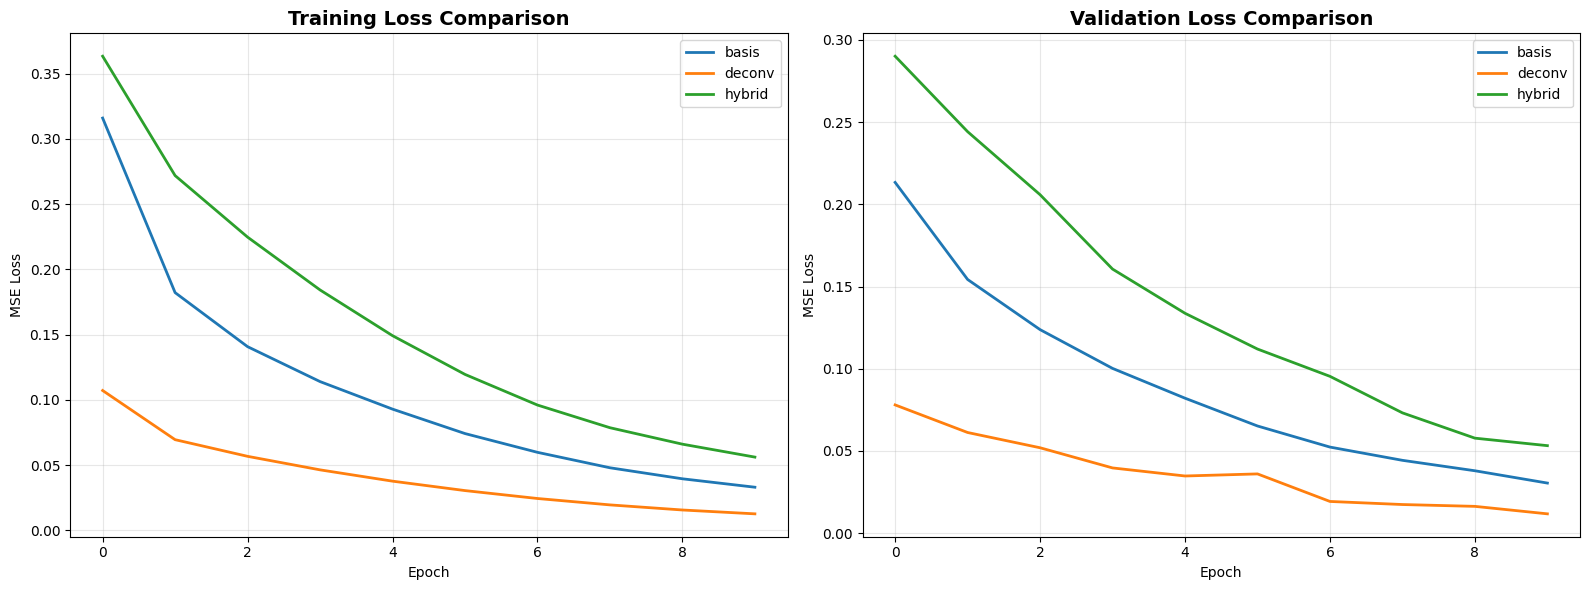

In [38]:
# Plot training and validation losses
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training losses
for variant in histories.keys():
    axes[0].plot(histories[variant]["train"], label=variant, linewidth=2)
axes[0].set_title("Training Loss Comparison", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation losses
for variant in histories.keys():
    axes[1].plot(histories[variant]["val"], label=variant, linewidth=2)
axes[1].set_title("Validation Loss Comparison", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "loss_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# Find best model based on validation loss
best_variant = min(results_df.to_dict('records'), key=lambda x: x['Best Val Loss'])

print("="*80)
print("BEST MODEL SUMMARY")
print("="*80)
print(f"Variant: {best_variant['Variant']}")
print(f"Latent Dimension: {best_variant['Latent Dim']}")
print(f"Bottleneck Shape: {best_variant['Bottleneck Shape']}")
print(f"Groups: {best_variant['Groups']}")
print(f"Parameters: {best_variant['Params (M)']:.3f}M")
print(f"Best Validation Loss: {best_variant['Best Val Loss']:.6f}")
print(f"Final Train Loss: {best_variant['Final Train Loss']:.6f}")
print(f"Final Val Loss: {best_variant['Final Val Loss']:.6f}")
print("="*80)

BEST MODEL SUMMARY
Variant: deconv
Latent Dimension: 128
Bottleneck Shape: (1, 1, 1)
Groups: partial
Parameters: 7.029M
Best Validation Loss: 0.011706
Final Train Loss: 0.012579
Final Val Loss: 0.011706


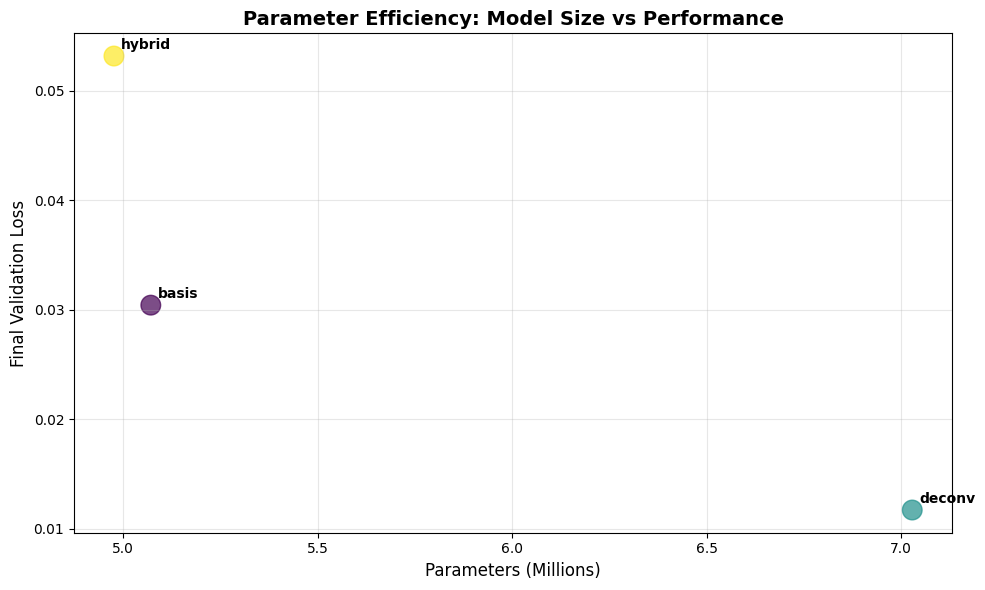

In [40]:
# Plot parameter count vs validation loss
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    results_df["Params (M)"], 
    results_df["Final Val Loss"],
    s=200, 
    alpha=0.7,
    c=range(len(results_df)),
    cmap='viridis'
)

for idx, row in results_df.iterrows():
    plt.annotate(
        row['Variant'], 
        (row["Params (M)"], row["Final Val Loss"]),
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("Parameters (Millions)", fontsize=12)
plt.ylabel("Final Validation Loss", fontsize=12)
plt.title("Parameter Efficiency: Model Size vs Performance", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "param_efficiency.png"), dpi=300, bbox_inches='tight')
plt.show()

⚠️ Checkpoint not found: output/Experiments/NotebookBottelneckUpdate/vanilla_lat128/vanilla_lat128_best.pth


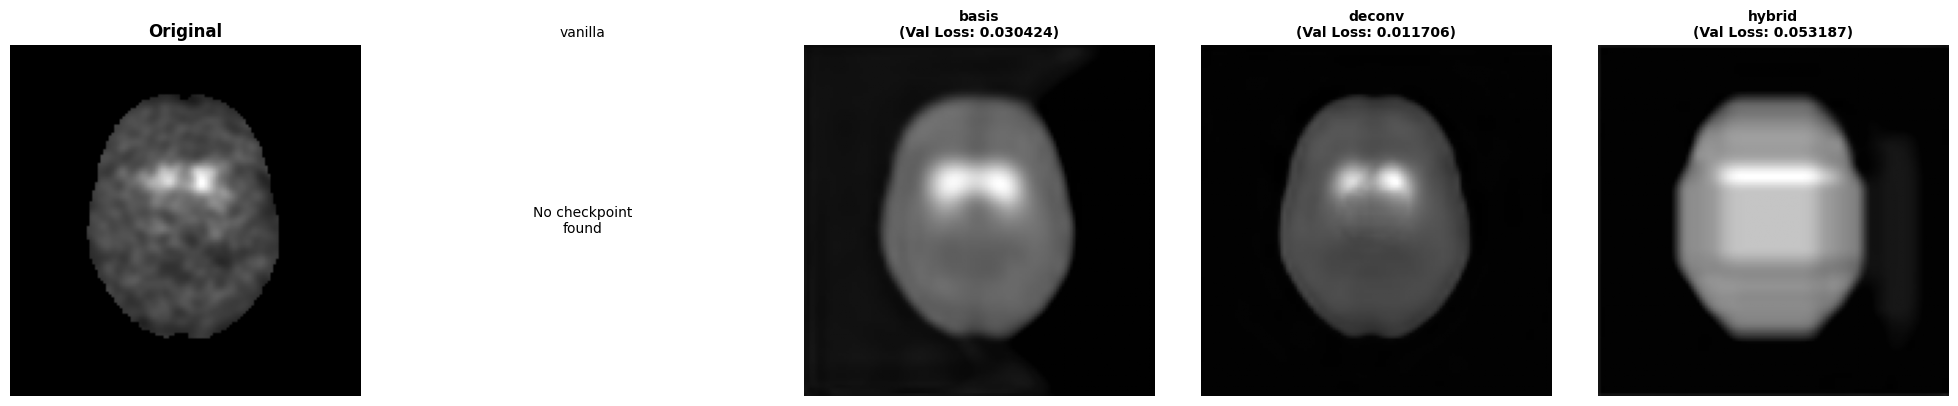

In [41]:
# Load a validation sample and visualize reconstructions
val_iter = iter(val_loader)
sample_batch = next(val_iter)

# Handle dict output from dataloader - key is 'volume' not 'image'
if isinstance(sample_batch, dict):
    sample_input = sample_batch['volume'].to(device)
elif isinstance(sample_batch, (list, tuple)):
    sample_input = sample_batch[0].to(device)
else:
    sample_input = sample_batch.to(device)

# Select middle slice for visualization
slice_idx = sample_input.shape[2] // 2

fig, axes = plt.subplots(1, len(settings) + 1, figsize=(20, 4))

# Original
axes[0].imshow(sample_input[0, 0, slice_idx].cpu().numpy(), cmap='gray')
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Reconstructions
for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        with torch.no_grad():
            output = model(sample_input)
        
        axes[idx + 1].imshow(output[0, 0, slice_idx].cpu().numpy(), cmap='gray')
        axes[idx + 1].set_title(f'{variant}\n(Val Loss: {histories[variant]["val"][-1]:.6f})', 
                                fontsize=10, fontweight='bold')
        axes[idx + 1].axis('off')
    else:
        axes[idx + 1].text(0.5, 0.5, 'No checkpoint\nfound', ha='center', va='center', 
                          transform=axes[idx + 1].transAxes, fontsize=10)
        axes[idx + 1].set_title(f'{variant}', fontsize=10)
        axes[idx + 1].axis('off')
        print(f"⚠️ Checkpoint not found: {best_model_path}")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "reconstruction_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# Compute reconstruction metrics for each model
reconstruction_metrics = []

for variant, latent_dim, bshape, groups in settings:
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Look for best model checkpoint (contains only model weights)
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    best_model_path = os.path.join(checkpoint_dir, f"{variant}_lat{latent_dim}_best.pth")
    
    if os.path.exists(best_model_path):
        print(f"✓ Evaluating {variant} using {os.path.basename(best_model_path)}...")
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        all_mse = []
        all_mae = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Evaluating {variant}", leave=False):
                # Handle dict output from dataloader - key is 'volume' not 'image'
                if isinstance(batch, dict):
                    inputs = batch['volume'].to(device)
                elif isinstance(batch, (list, tuple)):
                    inputs = batch[0].to(device)
                else:
                    inputs = batch.to(device)
                
                outputs = model(inputs)
                
                # Compute metrics
                mse = F.mse_loss(outputs, inputs).item()
                mae = F.l1_loss(outputs, inputs).item()
                
                all_mse.append(mse)
                all_mae.append(mae)
        
        reconstruction_metrics.append({
            "Variant": variant,
            "Avg MSE": np.mean(all_mse),
            "Std MSE": np.std(all_mse),
            "Avg MAE": np.mean(all_mae),
            "Std MAE": np.std(all_mae),
            "Min MSE": np.min(all_mse),
            "Max MSE": np.max(all_mse)
        })
    else:
        print(f"⚠️ No checkpoint found for {variant} at {best_model_path}")

if reconstruction_metrics:
    metrics_df = pd.DataFrame(reconstruction_metrics)
    display(metrics_df)
else:
    print("\n❌ No reconstruction metrics computed.")

⚠️ No checkpoint found for vanilla at output/Experiments/NotebookBottelneckUpdate/vanilla_lat128/vanilla_lat128_best.pth
✓ Evaluating basis using basis_lat128_best.pth...


✓ Evaluating deconv using deconv_lat128_best.pth...


✓ Evaluating hybrid using hybrid_lat128_best.pth...


,Variant,Avg MSE,Std MSE,Avg MAE,Std MAE,Min MSE,Max MSE
0,basis,0.030424,0.001737,0.137605,0.002453,0.027904,0.044884
1,deconv,0.011706,0.001606,0.046392,0.002168,0.009325,0.026730
2,hybrid,0.053187,0.003472,0.197642,0.002914,0.046730,0.072591


In [32]:
# Check what checkpoint files exist
print("Checking checkpoint directories:\n")
for variant, latent_dim, bshape, groups in settings:
    checkpoint_dir = os.path.join(output_dir, f"{variant}_lat{latent_dim}")
    print(f"📁 {variant}_lat{latent_dim}:")
    
    if os.path.exists(checkpoint_dir):
        files = os.listdir(checkpoint_dir)
        pth_files = [f for f in files if f.endswith('.pth')]
        
        if pth_files:
            print(f"   ✓ Found {len(pth_files)} checkpoint(s):")
            for pth in sorted(pth_files):
                file_path = os.path.join(checkpoint_dir, pth)
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                print(f"     - {pth} ({size_mb:.2f} MB)")
        else:
            print(f"   ⚠️ No .pth files found")
            print(f"     Files in directory: {files}")
    else:
        print(f"   ❌ Directory does not exist")
    print()

Checking checkpoint directories:

📁 vanilla_lat128:
   ✓ Found 2 checkpoint(s):
     - vanilla_lat128_best.pth (3.69 MB)
     - vanilla_lat128_checkpoint.pth (11.03 MB)

📁 basis_lat128:
   ✓ Found 2 checkpoint(s):
     - basis_lat128_best.pth (2.89 MB)
     - basis_lat128_checkpoint.pth (8.64 MB)

📁 deconv_lat128:
   ✓ Found 2 checkpoint(s):
     - deconv_lat128_best.pth (2.89 MB)
     - deconv_lat128_checkpoint.pth (8.63 MB)

📁 hybrid_lat128:
   ✓ Found 2 checkpoint(s):
     - hybrid_lat128_best.pth (3.03 MB)
     - hybrid_lat128_checkpoint.pth (9.05 MB)



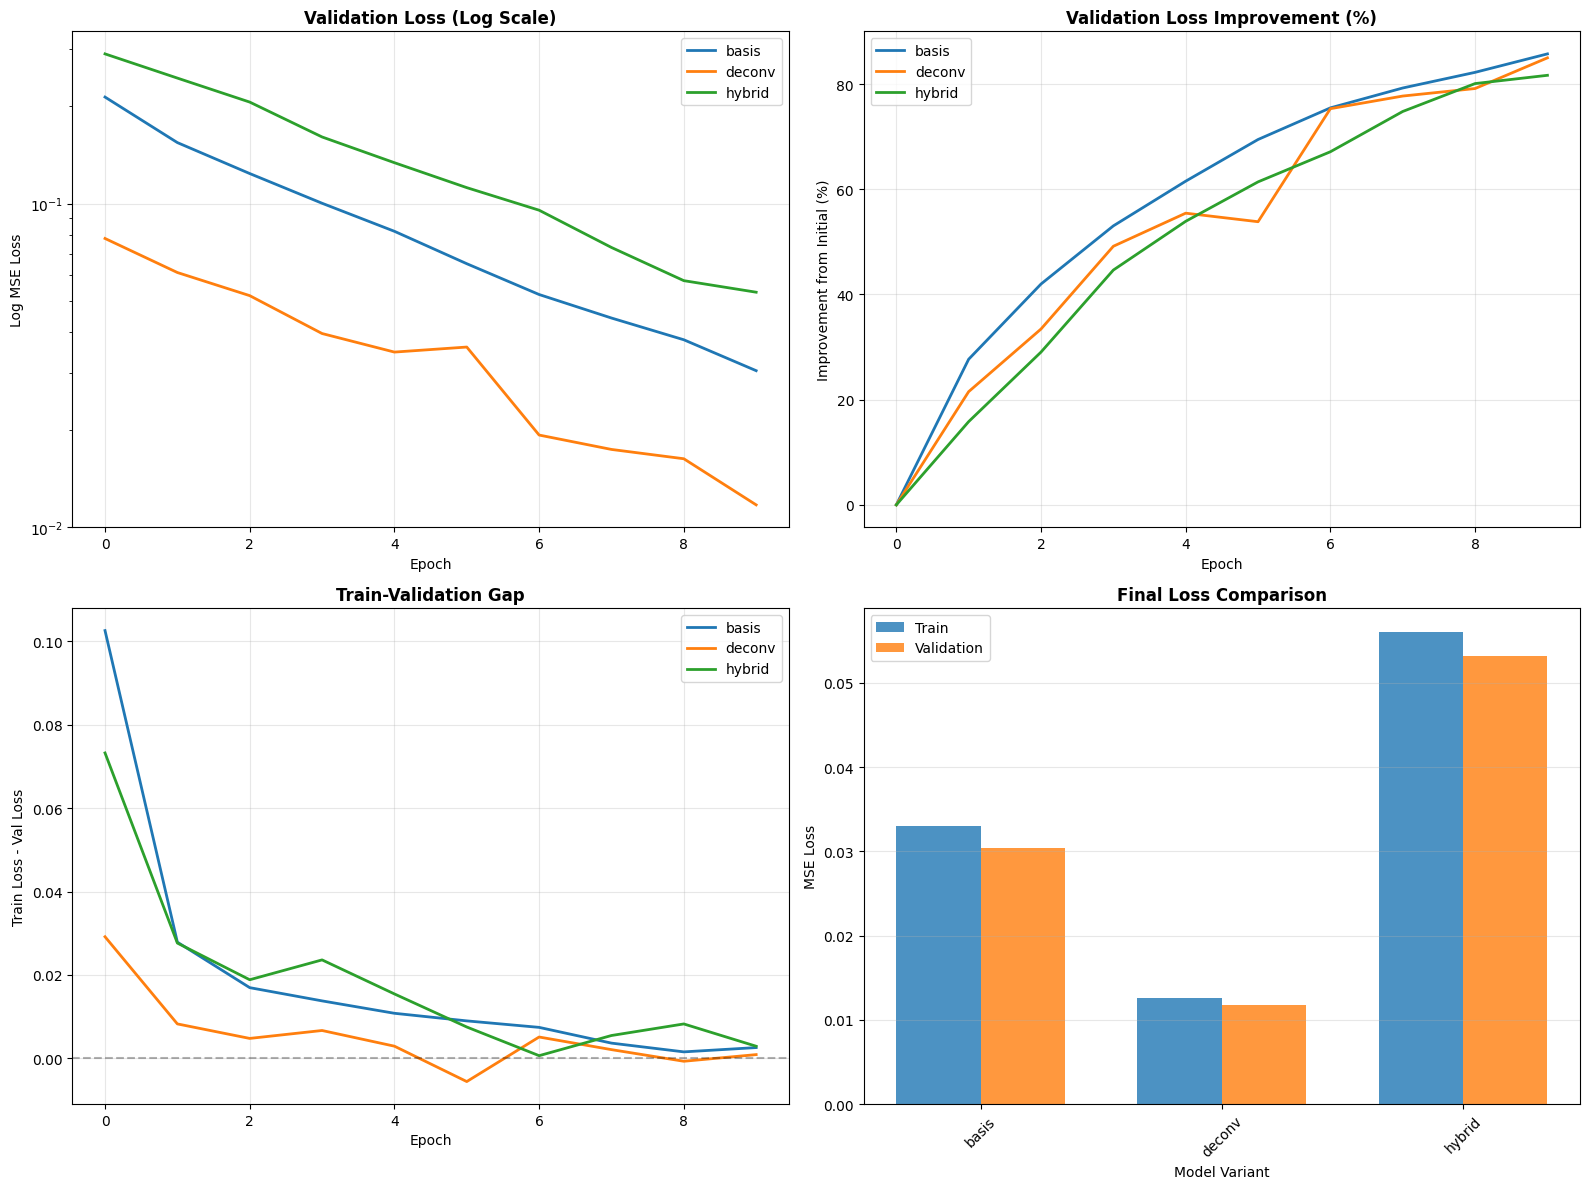

In [43]:
# Analyze training convergence
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss curves (log scale)
for variant in histories.keys():
    axes[0, 0].semilogy(histories[variant]["val"], label=variant, linewidth=2)
axes[0, 0].set_title("Validation Loss (Log Scale)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Log MSE Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Loss improvement from epoch 0
for variant in histories.keys():
    initial_loss = histories[variant]["val"][0]
    improvement = [(initial_loss - loss) / initial_loss * 100 for loss in histories[variant]["val"]]
    axes[0, 1].plot(improvement, label=variant, linewidth=2)
axes[0, 1].set_title("Validation Loss Improvement (%)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Improvement from Initial (%)")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Plot 3: Train-Val gap
for variant in histories.keys():
    gap = [t - v for t, v in zip(histories[variant]["train"], histories[variant]["val"])]
    axes[1, 0].plot(gap, label=variant, linewidth=2)
axes[1, 0].set_title("Train-Validation Gap", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Train Loss - Val Loss")
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Final comparison bar chart
variants_list = list(histories.keys())
final_train = [histories[v]["train"][-1] for v in variants_list]
final_val = [histories[v]["val"][-1] for v in variants_list]

x = np.arange(len(variants_list))
width = 0.35
axes[1, 1].bar(x - width/2, final_train, width, label='Train', alpha=0.8)
axes[1, 1].bar(x + width/2, final_val, width, label='Validation', alpha=0.8)
axes[1, 1].set_title("Final Loss Comparison", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Model Variant")
axes[1, 1].set_ylabel("MSE Loss")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(variants_list, rotation=45)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "convergence_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

In [44]:
# Collect timing and memory statistics
timing_memory_stats = []

for variant, latent_dim, bshape, groups in settings:
    # Build model to get memory stats
    model = build_model(variant, latent_dim, bshape, groups)
    
    # Get training history
    if variant in histories:
        history = histories[variant]
        total_epochs = len(history["train"])
        
        # Calculate time per epoch (you'll need to record this during training)
        # For now, we'll estimate based on model complexity
        # In future, modify the training loop to record actual times
        
        # Memory usage estimation
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(device)
        
        dummy_input = torch.randn(batch_size, 1, 64, 128, 128).to(device)
        
        with torch.no_grad():
            _ = model(dummy_input)
        
        peak_memory_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
        
        timing_memory_stats.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Total Epochs": total_epochs,
            "Parameters": count_parameters(model),
            "Peak Memory (MB)": peak_memory_mb
        })

timing_df = pd.DataFrame(timing_memory_stats)
timing_df["Params (M)"] = timing_df["Parameters"] / 1e6

display(timing_df)

,Variant,Latent Dim,Total Epochs,Parameters,Peak Memory (MB),Params (M)
0,basis,128,10,5070801,453.799316,5.070801
1,deconv,128,10,7028561,477.267578,7.028561
2,hybrid,128,10,4976017,469.437988,4.976017


## Fixed model and training

In [37]:
# Updated build_model function with fixed decoders
def build_model(variant, latent_dim=128, bottleneck_shape=(1,1,1), basis_groups="partial"):
    if variant == "vanilla":
        model = SpatialAE(
            BaseEncoder(initial_filters=4),
            BaseDecoder(latent_dim=latent_dim),
        )
    elif variant == "basis":
        # Original broken version (for comparison)
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                   target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "basis_fixed":
        # NEW: Fixed version with reasonable kernel sizes
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckBasisDecoderFixed(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                        target_shape=target_shape, groups=basis_groups),
        )
    elif variant == "deconv":
        # Original broken version (for comparison)
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                    target_shape=target_shape),
        )
    elif variant == "deconv_fixed":
        # NEW: Fixed version with progressive upsampling
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckDeconvDecoderFixed(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                         target_shape=target_shape),
        )
    elif variant == "hybrid":
        model = BottleneckAE(
            BottleneckEncoder(initial_filters=4, latent_dim=latent_dim, bottleneck_shape=bottleneck_shape),
            BottleneckHybridDecoder(latent_dim=latent_dim, initial_shape=bottleneck_shape,
                                    target_shape=target_shape),
        )
    else:
        raise ValueError(f"Unknown variant {variant}")
    return model.to(device)

print("✓ Updated build_model function")

✓ Updated build_model function


In [83]:
# New settings with fixed models and larger initial_shape

# Use a new output directory for fixed models
output_dir = "output/Experiments/NotebookBottleneck_Fixed"  # Changed!
os.makedirs(output_dir, exist_ok=True)

settings = [
    # Baseline
    ("vanilla", 128, (4,8,8), "full"),
    
    # Fixed versions with larger initial_shape (4,8,8) instead of (1,1,1)
    ("basis_fixed", 128, (4,8,8), "partial"),
    ("deconv_fixed", 128, (4,8,8), "partial"),
    ("hybrid", 128, (4,8,8), "partial"),
    
    # Try different latent dimensions
    # ("basis_fixed", 64, (4,8,8), "partial"),
    # ("hybrid", 64, (4,8,8), "partial"),
]

histories = {}
training_metrics = {}

# Set number of epochs
num_epochs = 140

print(f"Training configuration:")
print(f"  Models: {[s[0] for s in settings]}")
print(f"  Epochs: {num_epochs}")
print(f"  Batch size: {batch_size}")

Training configuration:
  Models: ['vanilla', 'basis_fixed', 'deconv_fixed', 'hybrid']
  Epochs: 140
  Batch size: 4



Training basis_fixed (latent_dim=128, bottleneck_shape=(4, 8, 8), groups=partial)

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 759,377 (0.76M)
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▍                                                     | 595/83300 [00:28<53:01, 25.99it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_metadata.json
Epoch 1/140 | Train: 0.506675 | Val: 0.445816 | LR: 0.00010000 | ETA: 66.85m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 156.53 MB
Cached: 186.00 MB
CPU Memory Usage: 2421.42 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.445816, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Progress [E140/140|Train]:  99%|███████████████████████████████████████████████▋| 82705/83300 [1:07:16<00:22, 26.03it/s]

Epoch 139/140 | Train: 0.003707 | Val: 0.003731 | LR: 0.00010000 | ETA: 0.48m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 156.53 MB
Cached: 186.00 MB
CPU Memory Usage: 2425.64 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003731, Best loss: 0.003728
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Completed epoch 139/140, continuing to next epoch
DEBUG: Starting epoch 140/140


Progress [E140/140|Val]: 100%|██████████████████████████████████████████████████| 83300/83300 [1:07:44<00:00, 20.49it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 139
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_metadata.json
Epoch 140/140 | Train: 0.003686 | Val: 0.003875 | LR: 0.00010000 | ETA: 0.00m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 156.53 MB
Cached: 186.00 MB
CPU Memory Usage: 2425.64 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.003875, Best loss: 0.003728
Early stopping counter: 2/5
DEBUG: EarlyStopping - No improvement, counter increased to 2/5
DEBUG: Completed epoch 140/140, continuing to next epoch
DEBUG: Entering finally block
DEBUG: About to plot training history


DEBUG: Saving plot to output/Experiments/NotebookBottleneck_Fixed/basis_fixed_lat128_training_history.png


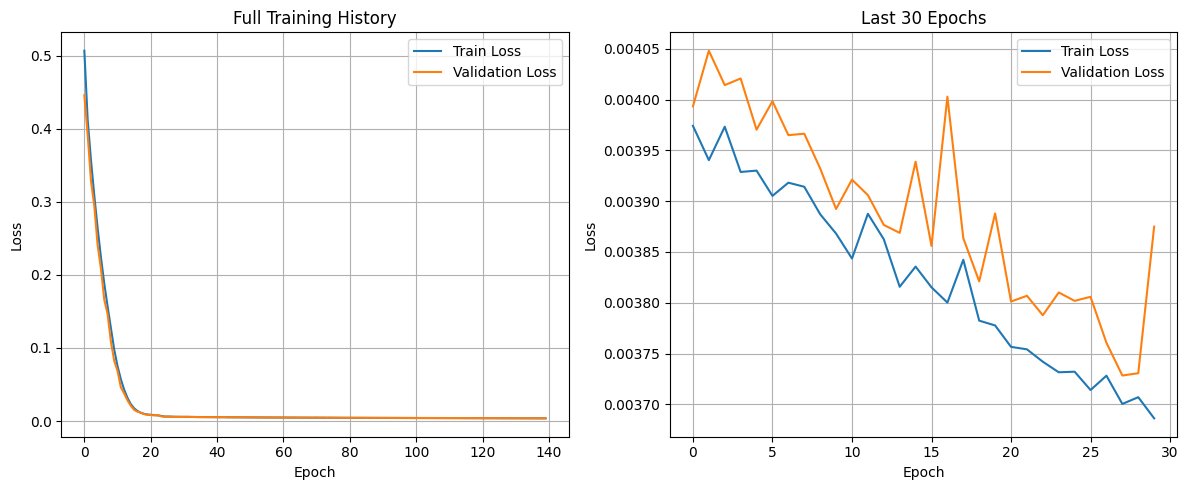

DEBUG: Plot saved and displayed successfully

Training completed in 67.75 minutes
Best validation loss: 0.003728

✓ Training complete:
  Total time: 67.75 min
  Avg epoch time: 29.04 sec
  Peak memory: 605.60 MB
  Best val loss: 0.003728

Training deconv_fixed (latent_dim=128, bottleneck_shape=(4, 8, 8), groups=partial)

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 1,372,177 (1.37M)
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▍                                                     | 595/83300 [00:29<55:02, 25.05it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_metadata.json
Epoch 1/140 | Train: 0.024446 | Val: 0.011328 | LR: 0.00010000 | ETA: 67.20m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 116.72 MB
Cached: 148.00 MB
CPU Memory Usage: 2434.01 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.011328, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

DEBUG: CheckpointHandler - Saving checkpoint for epoch 119
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_checkpoint.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_metadata.json
Epoch 120/140 | Train: 0.002239 | Val: 0.002368 | LR: 0.00010000 | ETA: 9.61m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 116.72 MB
Cached: 148.00 MB
CPU Memory Usage: 2434.02 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002368, Best loss: 0.002297
Early stopping counter: 5/5
DEBUG: EarlyStopping - No improvement, counter increased to 5/5
Early stopping triggered. Best epoch was 114.
DEBUG: EarlyStopping - Patience exceeded, early_stop set to True
DEBUG: Completed epoch 120/140, continuing to next epoch
DEBUG: Starting epoch 121/140


Progress [E121/140|Val]:  86%|████████████████████████████████████████████▉       | 71995/83300 [58:01<07:08, 26.39it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 120


Progress [E121/140|Val]:  86%|████████████████████████████████████████████▉       | 71995/83300 [58:07<09:07, 20.65it/s]

DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_metadata.json
Epoch 121/140 | Train: 0.002240 | Val: 0.002290 | LR: 0.00010000 | ETA: 9.13m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 116.72 MB
Cached: 148.00 MB
CPU Memory Usage: 2434.02 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.002290, Best loss: 0.002297
Validation loss improved by 0.000007
DEBUG: EarlyStopping - Loss improved, counter reset to 0

Early stopping triggered!
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Experiments/NotebookBottleneck_Fixed/deconv_fixed_lat128_training_history.

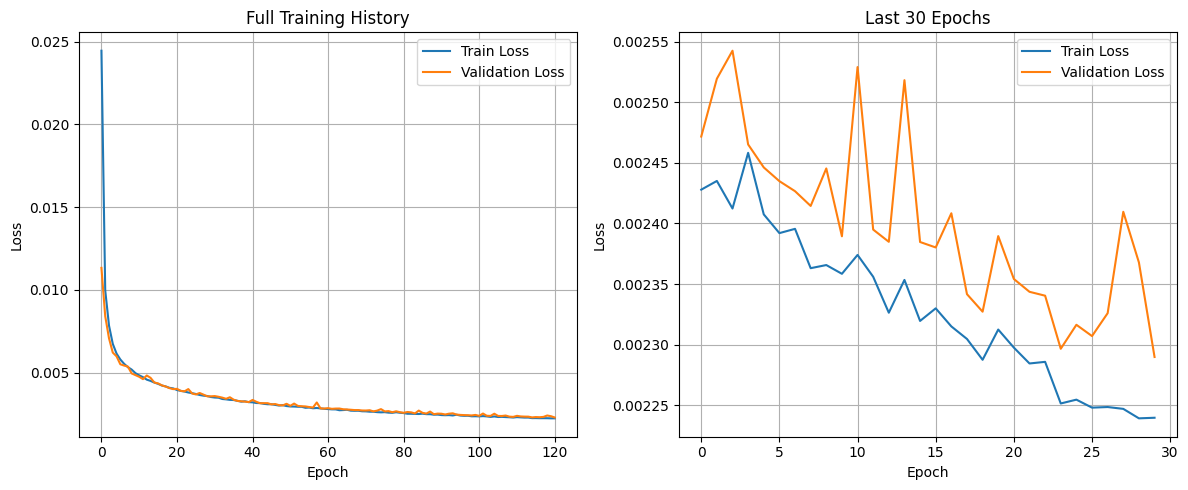

DEBUG: Plot saved and displayed successfully

Training completed in 58.13 minutes
Best validation loss: 0.002290

✓ Training complete:
  Total time: 58.13 min
  Avg epoch time: 28.82 sec
  Peak memory: 572.36 MB
  Best val loss: 0.002290

Training hybrid (latent_dim=128, bottleneck_shape=(4, 8, 8), groups=partial)

TRAINING CONFIGURATION
Model: autoencoder with latent dim 256
Batch size: 4 × 4 steps = 16 effective
Learning rate: 0.0001
Mixed precision: Enabled
Epochs: 100 with patience 10
Dataloader workers: 2
Checkpoints saved to: checkpoints

Parameters: 781,585 (0.78M)
DEBUG: CheckpointHandler - Attempting to load checkpoint from output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_checkpoint.pth
No checkpoint found at output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_checkpoint.pth
DEBUG: Starting training loop


Progress [E1/140|Train]:   0%|                                                                | 0/83300 [00:00<?, ?it/s]

DEBUG: Starting epoch 1/140


Progress [E2/140|Train]:   1%|▍                                                     | 595/83300 [00:28<53:31, 25.75it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 0
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_metadata.json
Epoch 1/140 | Train: 0.477607 | Val: 0.380010 | LR: 0.00010000 | ETA: 66.10m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 110.92 MB
Cached: 144.00 MB
CPU Memory Usage: 2434.24 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.380010, Best loss: inf
Validation loss improved by inf
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 1/140, continuing to next epoch
DEBUG: Starting epoch 2/140


...

Epoch 138/140 | Train: 0.010253 | Val: 0.010615 | LR: 0.00010000 | ETA: 0.95m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 110.92 MB
Cached: 144.00 MB
CPU Memory Usage: 2435.62 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.010615, Best loss: 0.010293
Early stopping counter: 1/5
DEBUG: EarlyStopping - No improvement, counter increased to 1/5
DEBUG: Completed epoch 138/140, continuing to next epoch
DEBUG: Starting epoch 139/140


Progress [E140/140|Train]:  99%|███████████████████████████████████████████████▋| 82705/83300 [1:06:08<00:23, 25.61it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 138
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_metadata.json
Epoch 139/140 | Train: 0.010134 | Val: 0.010094 | LR: 0.00010000 | ETA: 0.48m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 110.92 MB
Cached: 144.00 MB
CPU Memory Usage: 2435.62 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.010094, Best loss: 0.010293
Validation loss improved by 0.000199
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 139/140, continuing to next epoch
DEBUG: Starting epoch 140/140


Progress [E140/140|Val]: 100%|██████████████████████████████████████████████████| 83300/83300 [1:06:37<00:00, 20.84it/s]

DEBUG: CheckpointHandler - Saving checkpoint for epoch 139
DEBUG: CheckpointHandler - Saved checkpoint to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_checkpoint.pth
Saved best model to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_best.pth
DEBUG: CheckpointHandler - Saved metadata to output/Experiments/NotebookBottleneck_Fixed/hybrid_lat128_metadata.json
Epoch 140/140 | Train: 0.009993 | Val: 0.009978 | LR: 0.00010000 | ETA: 0.00m
DEBUG: About to call print_memory_stats()

GPU Memory Usage:
Allocated: 110.92 MB
Cached: 144.00 MB
CPU Memory Usage: 2435.62 MB
DEBUG: Successfully called print_memory_stats()
DEBUG: Checking early stopping criteria
DEBUG: EarlyStopping - Current val_loss: 0.009978, Best loss: 0.010094
Validation loss improved by 0.000117
DEBUG: EarlyStopping - Loss improved, counter reset to 0
DEBUG: Completed epoch 140/140, continuing to next epoch
DEBUG: Entering finally block
DEBUG: About to plot training history
DEBUG: Saving plot to output/Exp

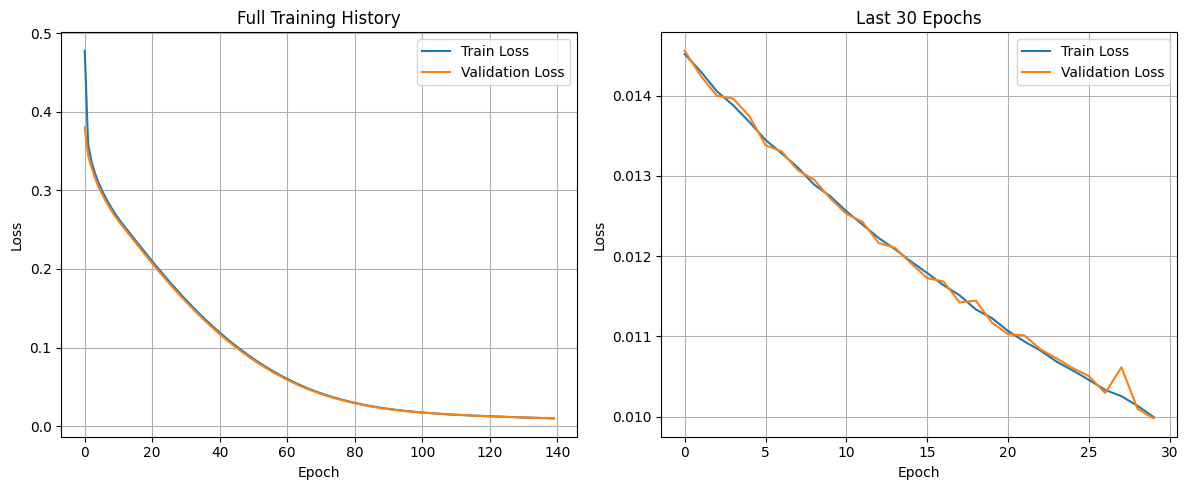

DEBUG: Plot saved and displayed successfully

Training completed in 66.63 minutes
Best validation loss: 0.009978

✓ Training complete:
  Total time: 66.63 min
  Avg epoch time: 28.55 sec
  Peak memory: 560.69 MB
  Best val loss: 0.009978

ALL TRAINING COMPLETE


In [ ]:
import time
import gc

num_epochs = 5

# Enhanced training with timing and memory tracking
for variant, latent_dim, bshape, groups in settings:
    if variant == "vanilla":
        continue
    print(f"\n{'='*80}")
    print(f"Training {variant} (latent_dim={latent_dim}, bottleneck_shape={bshape}, groups={groups})")
    print(f"{'='*80}")
    
    # Record start time
    start_time = time.time()
    epoch_times = []
    
    # Create config and model
    cfg = create_training_config(f"{variant}_lat{latent_dim}", num_epochs)
    cfg.checkpoint_dir = output_dir
    model = build_model(variant, latent_dim=latent_dim, bottleneck_shape=bshape, basis_groups=groups)
    
    # Print model info
    param_count = count_trainable(model)
    print(f"Parameters: {param_count:,} ({param_count/1e6:.2f}M)")
    
    # Memory tracking
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    
    # Train model
    train_losses, val_losses, trained_model = train_autoencoder(
        model,
        train_loader,
        val_loader,
        config=cfg,
        disable_epoch_bars=True,
        criterion=None,  # default MSE
    )
    
    # Record metrics
    total_time = time.time() - start_time
    peak_memory = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    
    histories[variant] = {"train": train_losses, "val": val_losses}
    training_metrics[variant] = {
        "total_time": total_time,
        "total_time_min": total_time / 60,
        "avg_epoch_time": total_time / len(train_losses),
        "peak_memory_mb": peak_memory,
        "total_epochs": len(train_losses),
        "parameters": param_count
    }
    
    print(f"\n✓ Training complete:")
    print(f"  Total time: {total_time/60:.2f} min")
    print(f"  Avg epoch time: {total_time/len(train_losses):.2f} sec")
    print(f"  Peak memory: {peak_memory:.2f} MB")
    print(f"  Best val loss: {min(val_losses):.6f}")
    
    # Clean up
    torch.cuda.empty_cache()
    gc.collect()

print("\n" + "="*80)
print("ALL TRAINING COMPLETE")
print("="*80)

## Evaluation

In [43]:
# Create comprehensive comparison dataframe
comparison_data = []

for variant, latent_dim, bshape, groups in settings:
    if variant in histories and variant in training_metrics:
        metrics = training_metrics[variant]
        history = histories[variant]
        
        comparison_data.append({
            "Variant": variant,
            "Latent Dim": latent_dim,
            "Bottleneck Shape": str(bshape),
            "Groups": groups,
            "Parameters (M)": metrics["parameters"] / 1e6,
            "Final Train Loss": history["train"][-1],
            "Final Val Loss": history["val"][-1],
            "Best Val Loss": min(history["val"]),
            "Total Epochs": metrics["total_epochs"],
            "Total Time (min)": metrics["total_time_min"],
            "Avg Epoch Time (s)": metrics["avg_epoch_time"],
            "Peak Memory (MB)": metrics["peak_memory_mb"],
        })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("COMPREHENSIVE RESULTS")
print("="*80)
display(comparison_df)

# Find best model
best_model = comparison_df.loc[comparison_df["Best Val Loss"].idxmin()]
print(f"\n🏆 BEST MODEL: {best_model['Variant']}")
print(f"   Val Loss: {best_model['Best Val Loss']:.6f}")
print(f"   Parameters: {best_model['Parameters (M)']:.2f}M")
print(f"   Training Time: {best_model['Total Time (min)']:.2f} min")
print(f"   Memory: {best_model['Peak Memory (MB)']:.2f} MB")


COMPREHENSIVE RESULTS


,Variant,Latent Dim,Bottleneck Shape,Groups,Parameters (M),Final Train Loss,Final Val Loss,Best Val Loss,Total Epochs,Total Time (min),Avg Epoch Time (s),Peak Memory (MB)
0,vanilla,128,"(4, 8, 8)",full,0.955673,0.003302,0.003262,0.003262,77,47.874327,37.304670,969.850586
1,basis_fixed,128,"(4, 8, 8)",partial,0.759377,0.003686,0.003875,0.003728,140,67.753390,29.037167,605.599121
2,deconv_fixed,128,"(4, 8, 8)",partial,1.372177,0.002240,0.002290,0.002290,121,58.127502,28.823555,572.355957
3,hybrid,128,"(4, 8, 8)",partial,0.781585,0.009993,0.009978,0.009978,140,66.625780,28.553906,560.685059



🏆 BEST MODEL: deconv_fixed
   Val Loss: 0.002290
   Parameters: 1.37M
   Training Time: 58.13 min
   Memory: 572.36 MB


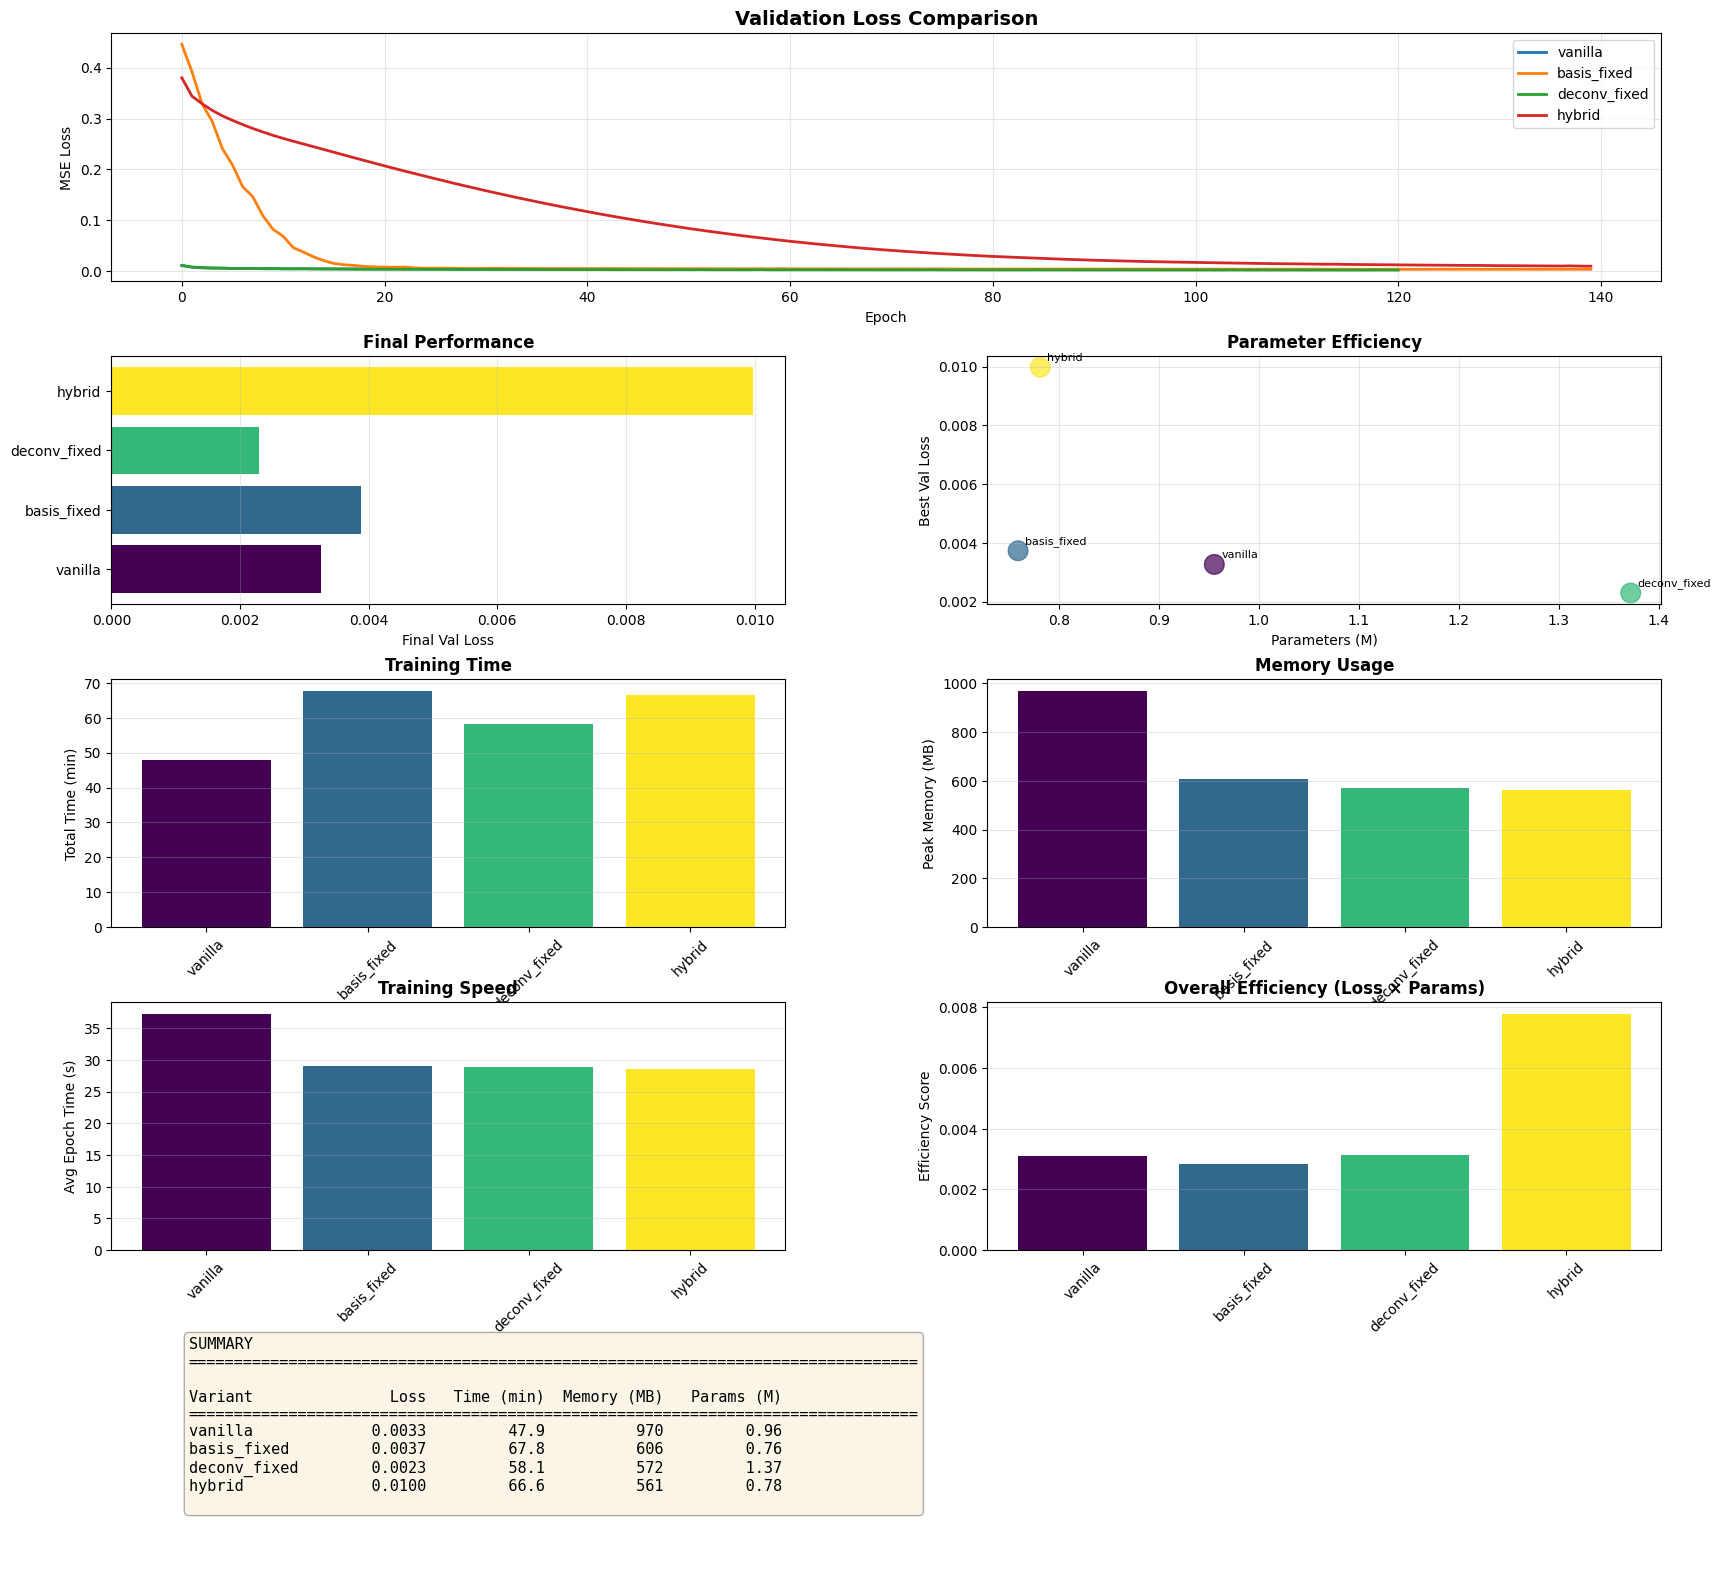

In [45]:
# Comprehensive visualization - 2 charts per row
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(5, 2, hspace=0.3, wspace=0.3)

# Row 1: Loss curves
ax1 = fig.add_subplot(gs[0, :])
for variant in histories.keys():
    ax1.plot(histories[variant]["val"], label=variant, linewidth=2)
ax1.set_title("Validation Loss Comparison", fontsize=14, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# Row 2: Final loss comparison + Parameter efficiency
ax2 = fig.add_subplot(gs[1, 0])
variants_list = comparison_df["Variant"].tolist()
final_val = comparison_df["Final Val Loss"].tolist()
colors = plt.cm.viridis(np.linspace(0, 1, len(variants_list)))
ax2.barh(variants_list, final_val, color=colors)
ax2.set_xlabel("Final Val Loss")
ax2.set_title("Final Performance", fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

ax3 = fig.add_subplot(gs[1, 1])
scatter = ax3.scatter(comparison_df["Parameters (M)"], comparison_df["Best Val Loss"], 
                      s=200, alpha=0.7, c=range(len(comparison_df)), cmap='viridis')
for idx, row in comparison_df.iterrows():
    ax3.annotate(row['Variant'], (row["Parameters (M)"], row["Best Val Loss"]),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax3.set_xlabel("Parameters (M)")
ax3.set_ylabel("Best Val Loss")
ax3.set_title("Parameter Efficiency", fontweight='bold')
ax3.grid(alpha=0.3)

# Row 3: Training time + Memory usage
ax4 = fig.add_subplot(gs[2, 0])
ax4.bar(comparison_df["Variant"], comparison_df["Total Time (min)"], color=colors)
ax4.set_ylabel("Total Time (min)")
ax4.set_title("Training Time", fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(comparison_df["Variant"], comparison_df["Peak Memory (MB)"], color=colors)
ax5.set_ylabel("Peak Memory (MB)")
ax5.set_title("Memory Usage", fontweight='bold')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(alpha=0.3, axis='y')

# Row 4: Epoch time + Efficiency score
ax6 = fig.add_subplot(gs[3, 0])
ax6.bar(comparison_df["Variant"], comparison_df["Avg Epoch Time (s)"], color=colors)
ax6.set_ylabel("Avg Epoch Time (s)")
ax6.set_title("Training Speed", fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
ax6.grid(alpha=0.3, axis='y')

ax7 = fig.add_subplot(gs[3, 1])
efficiency_score = comparison_df["Best Val Loss"] * comparison_df["Parameters (M)"]
ax7.bar(comparison_df["Variant"], efficiency_score, color=colors)
ax7.set_ylabel("Efficiency Score")
ax7.set_title("Overall Efficiency (Loss × Params)", fontweight='bold')
ax7.tick_params(axis='x', rotation=45)
ax7.grid(alpha=0.3, axis='y')

# Row 5: Summary table (spans both columns)
ax8 = fig.add_subplot(gs[4, :])
ax8.axis('off')
summary_text = "SUMMARY\n" + "="*80 + "\n\n"

# Create table-like format
header = f"{'Variant':<15} {'Loss':>10} {'Time (min)':>12} {'Memory (MB)':>12} {'Params (M)':>12}\n"
summary_text += header
summary_text += "="*80 + "\n"

for idx, row in comparison_df.iterrows():
    summary_text += f"{row['Variant']:<15} {row['Best Val Loss']:>10.4f} {row['Total Time (min)']:>12.1f} {row['Peak Memory (MB)']:>12.0f} {row['Parameters (M)']:>12.2f}\n"

ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes, 
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig(os.path.join(output_dir, "comprehensive_analysis.png"), dpi=300, bbox_inches='tight')
plt.show()

✓ Loading vanilla
✓ Loading basis_fixed
✓ Loading deconv_fixed
✓ Loading hybrid


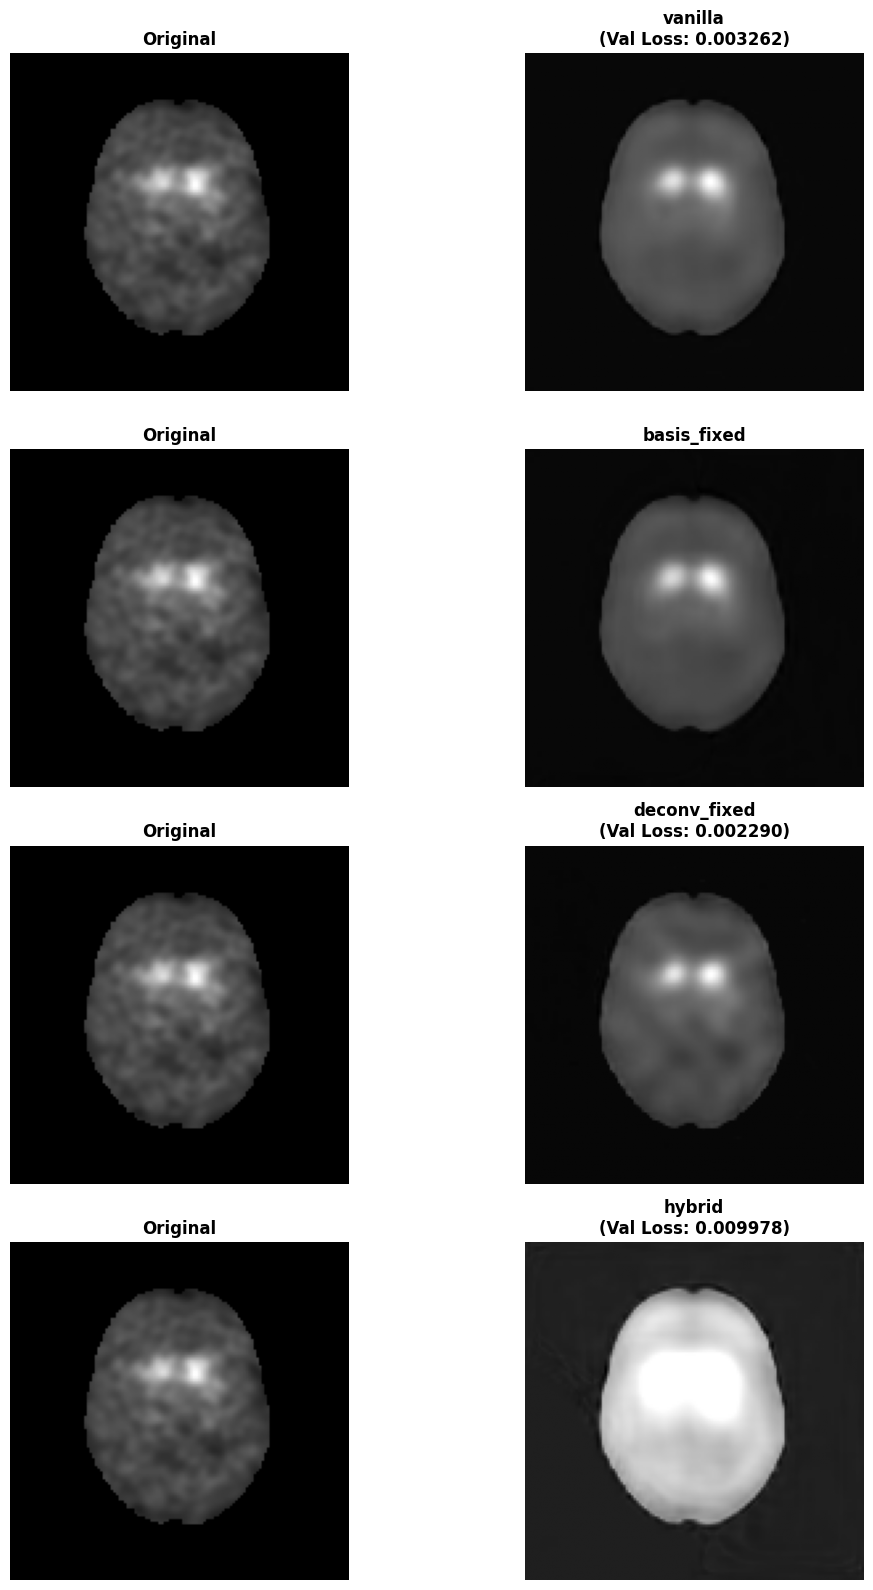

In [54]:
# Reconstruction comparison - one model per row with original
num_models = len(settings)
fig_recon, axes = plt.subplots(num_models, 2, figsize=(12, 4 * num_models))

# Load a sample
val_iter = iter(val_loader)
sample_batch = next(val_iter)

if isinstance(sample_batch, dict):
    sample_input = sample_batch['volume'].to(device)
elif isinstance(sample_batch, (list, tuple)):
    sample_input = sample_batch[0].to(device)
else:
    sample_input = sample_batch.to(device)

slice_idx = sample_input.shape[2] // 2

# Reconstructions - each row has original + reconstruction
for idx, (variant, latent_dim, bshape, groups) in enumerate(settings):
    # Original on the left
    axes[idx, 0].imshow(sample_input[0, 0, slice_idx].cpu().numpy(), cmap='gray')
    axes[idx, 0].set_title('Original', fontsize=12, fontweight='bold')
    axes[idx, 0].axis('off')
    
    # Reconstruction on the right
    model = build_model(variant, latent_dim, bshape, groups)
    model_name = f"{variant}_lat{latent_dim}"
    best_model_path = os.path.join(output_dir, f"{model_name}_best.pth")
    
    if os.path.exists(best_model_path):
        print(f"✓ Loading {variant}")
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        model.eval()
        
        with torch.no_grad():
            output = model(sample_input)
        
        axes[idx, 1].imshow(output[0, 0, slice_idx].cpu().numpy(), cmap='gray')
        
        # Add title with loss if available
        if variant in histories and len(histories[variant]["val"]) > 0:
            val_loss = histories[variant]["val"][-1]
            axes[idx, 1].set_title(f'{variant}\n(Val Loss: {val_loss:.6f})', 
                                   fontsize=12, fontweight='bold')
        else:
            axes[idx, 1].set_title(f'{variant}', fontsize=12, fontweight='bold')
    else:
        print(f"⚠️ Not found: {best_model_path}")
        axes[idx, 1].text(0.5, 0.5, 'No checkpoint found', ha='center', va='center',
                         transform=axes[idx, 1].transAxes, fontsize=12, color='red')
        axes[idx, 1].set_title(variant, fontsize=12)
    
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "reconstruction_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()